In [ ]:

import torch
import matplotlib.pyplot as plt
import os

os.chdir("..")
from utils import *
from core.SimulationEnvironment import *
from core.models import *
from config.constants import *
from config.two_bond_parameters import *
from training.pretraining_actor import *
from training.pretraining_critic import *
from training.train import *
device_used = "cpu" #torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
SELECTED_BONDS = [4, 6, 7, 11, 13, 14, 17, 18] # most volatile bonds as in the paper

SIGMA = np.array(COV[np.ix_(SELECTED_BONDS, SELECTED_BONDS)])   

INTENSITIES = ARRIVAL_RATES[SELECTED_BONDS]            
SIZES = AVG_SIZES[SELECTED_BONDS]                   
NB_BONDS = len(SELECTED_BONDS)
alpha = np.array(ALPHA[SELECTED_BONDS])                        
beta = np.array(BETA[SELECTED_BONDS])                           
mu = np.array(MU[SELECTED_BONDS])                                
scale = np.array(SCALE[SELECTED_BONDS])                         

LB_RISK = -3 * SIZES
UB_RISK =  3 * SIZES



In [3]:
# Initialize market
market_simulator = Market(
    lambdas_RFQ=INTENSITIES,
    Sigma=SIGMA,
    rf=RF,
    sizes=SIZES,
    f_parameters=(alpha, beta, mu, scale),
)



In [4]:
# Initialize models
actors = [Actor(NB_BONDS, HIDDEN_DIM) for _ in range(NB_BONDS)]
critic = Critic(state_dim = NB_BONDS, hidden= HIDDEN_DIM)

In [ ]:

# Pretrain actors if not found
for j in SELECTED_BONDS:
    path = f"pretrained_actors/actor_{j}_{len(SELECTED_BONDS)}_scenario.pt"

    if not os.path.exists(path):
        myopic_p, myopic_delta = myopic_probs(
            d=NB_BONDS,
            market_env=market_simulator
        )

        for i in range(NB_BONDS):
            pretrain_actor(
                actors[i],
                myopic_p[i],
                LB_RISK,
                UB_RISK,
                avg_sizes=SIZES,
                device=device_used
            )
        
        save_pretrained_actors(actors, SELECTED_BONDS)

In [ ]:
# Pretrain Critic if not found
path = f"pretrained_critic/critic_bonds_{SELECTED_BONDS}_{len(SELECTED_BONDS)}_bond_scenario.pt"
if not os.path.exists(path):
    myopic_p, myopic_delta = myopic_probs(
                d=NB_BONDS,
                market_env=market_simulator
            )

    critic_target, critic_input = produce_initial_value_grid(market_simulator, 
                                                            init_strategy= myopic_p,
                                                            lb_risk=LB_RISK, ub_risk=UB_RISK, nb_bonds=NB_BONDS, sizes=SIZES)

    critic = pretrain_critic(
        critic=critic,
        input= critic_input/SIZES.reshape(1, -1),
        target= critic_target
    )
    save_pretrained_critic(critic, list(SELECTED_BONDS))


In [7]:
# load the critic
critic = Critic(state_dim= NB_BONDS, hidden= HIDDEN_DIM)
save_path = os.path.join(f"pretrained_critic/critic_bonds_{SELECTED_BONDS}_{len(SELECTED_BONDS)}_bond_scenario.pt")
state_dict = torch.load(save_path, map_location="cpu") 
critic.load_state_dict(state_dict)
critic.to(device_used)

# and the actors 
actors = [Actor(state_dim=NB_BONDS, hidden=HIDDEN_DIM) for i in range(NB_BONDS)]
for i, b in enumerate(SELECTED_BONDS):
    path = f"pretrained_actors/actor_{b}_pretrained.pt"
    state_dict = torch.load(path, map_location="cpu") 
    actors[i].load_state_dict(state_dict)
    actors[i].to(device_used)


C:\Users\tsito\AppData\Local\Temp\ipykernel_22816\3906147767.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(save_path, map_location="cpu")
C:\Us

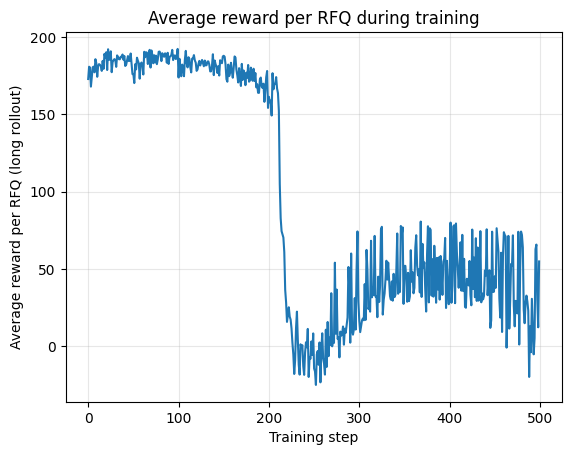

In [8]:
results = train_final(
    actors = actors,
    critic= critic,
    market=market_simulator,
    r= RF,
    Sigma= SIGMA,
    nb_steps=NB_STEPS,
    avg_sizes= SIZES,
    critic_batch_size=CRITIC_BATCH_SIZE, 
    actor_batch_size=ACTOR_BATCH_SIZE,
    critic_lr= 1e-3, 
    actor_lr= 1e-4,
    LB_init=LB_INIT[SELECTED_BONDS],
    UB_init=UB_INIT[SELECTED_BONDS], 
    LB_max=LB_FINAL[SELECTED_BONDS],
    UB_max=UB_FINAL[SELECTED_BONDS],
    nb_short_rollouts= 100, 
    short_horizon= 100, 
    long_horizon= LONG_HORIZON,
    update_risk_after= 50
)

In [13]:
myopic_p, myopic_delta = myopic_probs(
            d=NB_BONDS,
            market_env=market_simulator
        )

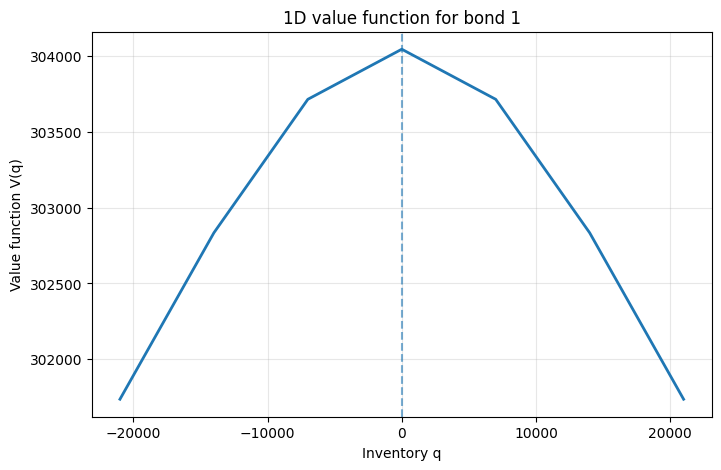

In [16]:
import matplotlib.pyplot as plt

grid, V = solve_1d_value_fixed_policy(
    market=market_simulator,
    i=i,
    LB_i=LB_INIT[0],
    UB_i=UB_INIT[0]+AVG_SIZES[0],
    rfq_size=AVG_SIZES[0],
    delta_bid=myopic_delta[0],
    delta_ask=myopic_delta[0],
)

plt.figure(figsize=(8, 5))
plt.plot(grid, V, linewidth=2)
plt.axvline(0.0, linestyle="--", alpha=0.6)
plt.xlabel("Inventory q")
plt.ylabel("Value function V(q)")
plt.title(f"1D value function for bond {i}")
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

critic.eval()

device = next(critic.parameters()).device

grid = np.arange(LB_RISK[0], UB_RISK[0] + 1e-12, AVG_SIZES[0], dtype=np.float32)

# critic was trained on inventories normalized by avg sizes
X = (grid / AVG_SIZES[0]).reshape(-1, 1)

with torch.no_grad():
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    V = critic(X_t)
    if V.dim() == 2 and V.shape[1] == 1:
        V = V[:, 0]
    V = V.detach().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.plot(grid, V, linewidth=2, label="Learned critic")
plt.axvline(0.0, linestyle="--", alpha=0.6)
plt.xlabel("Inventory q")
plt.ylabel("Critic value")
plt.title("Learned value function")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (6x1 and 2x12)

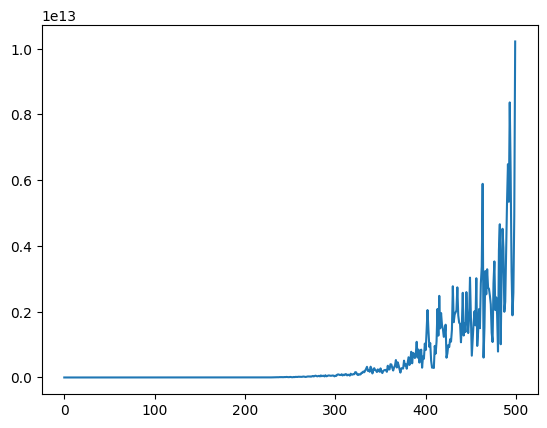

In [9]:
plt.plot(results["critic_loss"])

In [10]:
S_long, A_base_long, A_noisy_long, D_long, R_long, S_trade_long = rollout(
    policy=actors,
    starting_inventory=np.zeros(NB_BONDS),
    horizon=1000,
    market=market_simulator,
    r=RF,
    Sigma=SIGMA,
    lb= LB_INIT[SELECTED_BONDS], 
    ub= UB_INIT[SELECTED_BONDS],
    avg_sizes= SIZES
)

R_long = np.asarray(R_long, dtype=float).reshape(-1)
r_bar = float(R_long.mean()) if R_long.size > 0 else 0.0
print("Average reward per RFQ (Trained actor):", r_bar)

Average reward per RFQ (Trained actor): 72.22118077468872


In [11]:
actors[0](torch.tensor(np.zeros(NB_BONDS), dtype=torch.float32))
mm = MarketMaker(GAMMA, np.zeros(NB_BONDS, dtype=float), UB_INIT[SELECTED_BONDS], LB_INIT[SELECTED_BONDS], market_simulator)



for _ in range(5):
    print(mm.update_batch(np.array([np.array([0])]), SIGMA, RF, 0, 1, np.array([0.01])))

TypeError: MarketMaker.update_batch() missing 1 required positional argument: 'avg_sizes'